# Customer Churn Prediction

In [12]:
import pandas as pd

# Load the dataset
file_path = '../resources/online_retail_customer_churn.csv'
data = pd.read_csv(file_path)

# Display the first few rows to review the structure of the data
data.head()



file_path = '../resources/processed_customer_churn_data.csv'
data = pd.read_csv(file_path)

data.head()

,Customer_ID,Age,Annual_Income,Total_Spend,Years_as_Customer,Num_of_Purchases,Average_Transaction_Amount,Num_of_Returns,Num_of_Support_Contacts,Satisfaction_Score,...,Promotion_Response_Responded,Promotion_Response_Unsubscribed,Email_Opt_In_True,Return_Ratio,Purchase_Frequency,Promotion_Response_Score,Email_Opt_In_Score,Engagement_Score,CLV,Intervention_Cost
0,1,62,45.15,5892.58,5,22,453.80,2,0,3,...,True,False,True,0.090909,0.170543,3,1,4,386.961240,50
1,2,65,79.51,9025.47,13,77,22.90,2,2,3,...,True,False,False,0.025974,0.339207,3,0,3,100.981938,50
2,3,18,29.19,618.83,13,71,50.53,5,2,2,...,True,False,False,0.070423,0.250883,3,0,3,164.802792,50
3,4,21,79.63,9110.30,3,33,411.83,5,3,5,...,False,False,True,0.151515,0.146018,1,1,2,180.403407,50
4,5,21,77.66,5390.88,15,43,101.19,3,0,5,...,False,True,False,0.069767,0.177686,0,0,0,269.700620,50


## Random Forest

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

# Function to train Random Forest model and save it
def train_and_save_model(data, feature_cols, target_col, model_path='../models/rf_churn_model.pkl'):
    X = data[feature_cols]
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model = RandomForestClassifier(class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    joblib.dump(model, model_path)
    print(f"Random Forest model saved to {model_path}")

    # Evaluate model
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", conf_matrix)

# Function to load the model and apply utility-based decision rule
def load_model_and_decide(new_data, feature_cols, model_path='../models/rf_churn_model.pkl'):
    model = joblib.load(model_path)

    churn_probs = model.predict_proba(new_data[feature_cols])[:, 1]

    new_data = new_data.copy()
    new_data['Churn_Prob'] = churn_probs

    # Apply utility-based decision rule
    new_data['Expected_Utility'] = (
        new_data['Churn_Prob'] * new_data['CLV'] - new_data['Intervention_Cost']
    )

    threshold = 0.35

    new_data['Intervention'] = np.where(
        (new_data['Churn_Prob'] >= threshold) & (new_data['Expected_Utility'] > 0),
        'send_promotion',
        'no_action'
)


    return new_data[['Customer_ID', 'Churn_Prob', 'CLV', 'Expected_Utility', 'Intervention']]

# Example usage

    # Load processed data
data = pd.read_csv('../resources/processed_customer_churn_data.csv')

    # Define features and target
feature_columns = [
        'Return_Ratio', 'Purchase_Frequency', 'Engagement_Score', 'CLV',
        'Gender_Male', 'Promotion_Response_Responded', 'Promotion_Response_Unsubscribed',
        'Email_Opt_In_Score'
    ]
target_column = 'Target_Churn'

    # Train and save the model
train_and_save_model(data, feature_columns, target_column)

    # Load and apply model to example decision data
test_data = data.sample(n=10, random_state=42)
decisions = load_model_and_decide(test_data, feature_columns)

print(decisions)

Random Forest model saved to ../models/rf_churn_model.pkl
Accuracy: 0.5733
Precision: 0.5915
Recall: 0.6139
F1 Score: 0.6025
Confusion Matrix:
 [[75 67]
 [61 97]]
     Customer_ID  Churn_Prob          CLV  Expected_Utility    Intervention
521          522        0.88   485.220950        376.994436  send_promotion
737          738        0.48    48.888348        -26.533593       no_action
740          741        0.83   761.231244        581.821932  send_promotion
660          661        0.63   386.284472        193.359217  send_promotion
411          412        0.19  2669.412857        457.188443       no_action
678          679        0.25    67.322727        -33.169318       no_action
626          627        0.81  5065.028571       4052.673143  send_promotion
513          514        0.88   244.069091        164.780800  send_promotion
859          860        0.86   139.702909         70.144502  send_promotion
136          137        0.82    13.900073        -38.601940       no_action


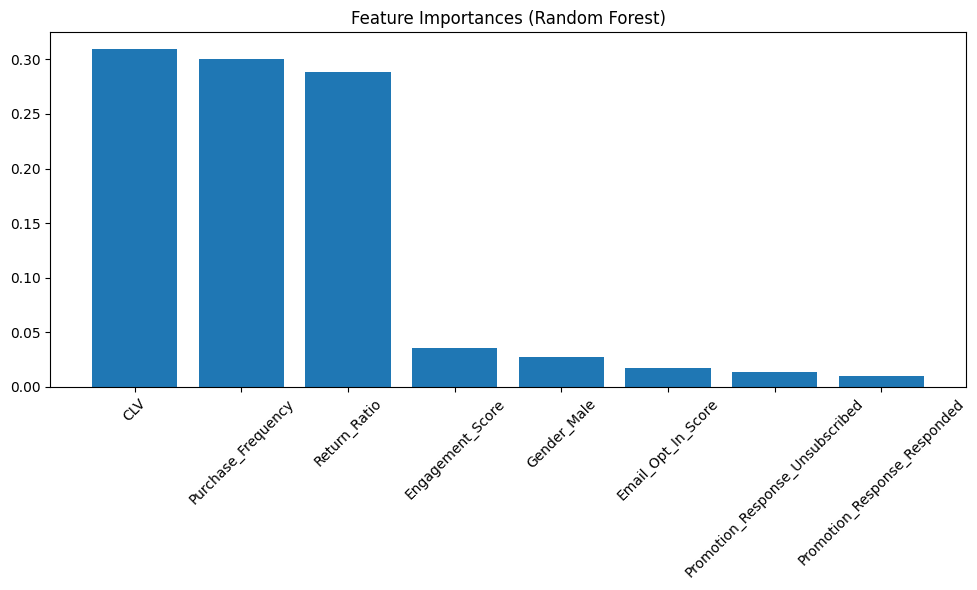

In [7]:
import matplotlib.pyplot as plt

# Load model if not already in memory
model = joblib.load('../models/rf_churn_model.pkl')

# Get feature importances
importances = model.feature_importances_
feature_names = [
    'Return_Ratio', 'Purchase_Frequency', 'Engagement_Score', 'CLV',
    'Gender_Male', 'Promotion_Response_Responded', 'Promotion_Response_Unsubscribed',
    'Email_Opt_In_Score'
]

# Create a sorted plot
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

## RL Agent Integration

Goal: Use our actual churn model + bandit agent to decide promotions

What we will integrate:

| Churn_Prob | From your trained model (e.g., Random Forest)
| CLV, Engagement_Score, etc. | Already in processed_customer_churn_data.csv
| Action (promotion or not) | Bandit agent (Thompson Sampling)
| Reward | Based on real action & churn probability

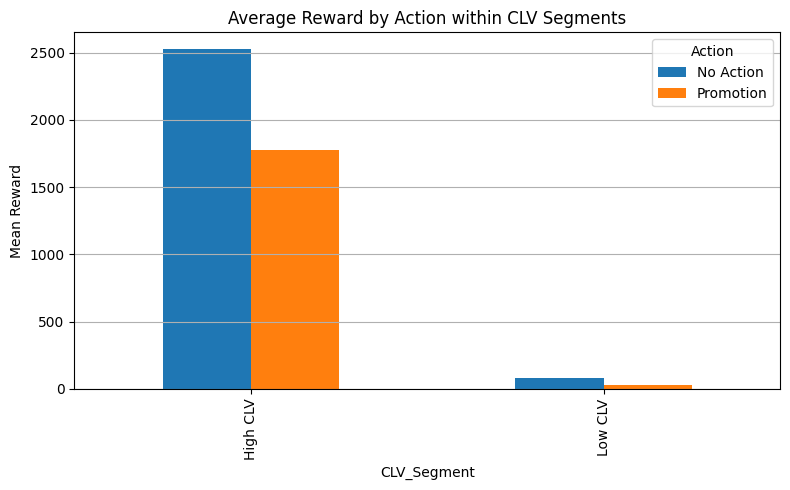

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_17256\3854380820.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segmented_churn = results.groupby(["Churn_Segment", "Action"])["Reward"].mean().unstack()


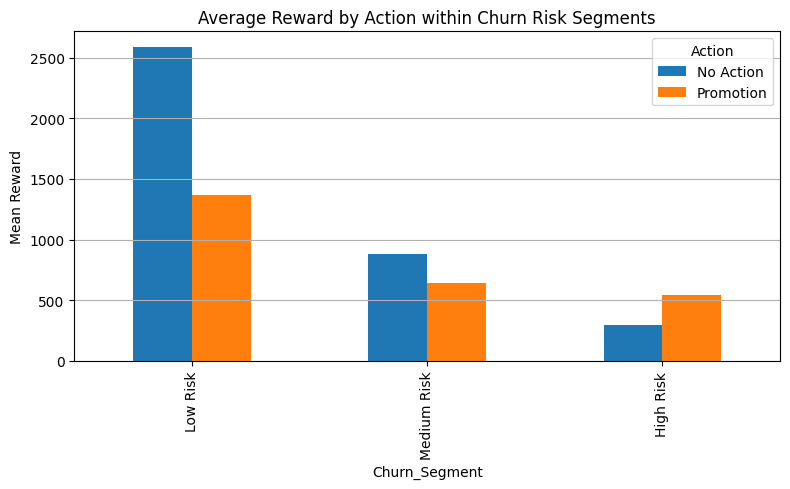

Saved to bandit_recommendations_with_real_churn_probs.csv


In [8]:
# SECTION 1: Import Libraries & Load Data + Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load processed dataset
data = pd.read_csv("../resources/processed_customer_churn_data.csv")

# Load trained churn model (ensure same sklearn version used for training!)
model = joblib.load("../models/rf_churn_model.pkl")

# Define feature columns for prediction
feature_columns = [
    'Return_Ratio', 'Purchase_Frequency', 'Engagement_Score', 'CLV',
    'Gender_Male', 'Promotion_Response_Responded', 'Promotion_Response_Unsubscribed',
    'Email_Opt_In_Score'
]

# SECTION 2: Generate Churn Probabilities from your Model
X = data[feature_columns]
data["Churn_Prob"] = model.predict_proba(X)[:, 1]

# SECTION 3: Define Thompson Sampling Bandit
class ThompsonSamplingBandit:
    def __init__(self):
        self.success_counts = np.ones(2)
        self.failure_counts = np.ones(2)

    def select_action(self):
        sampled_probs = np.random.beta(self.success_counts, self.failure_counts)
        return np.argmax(sampled_probs)

    def update(self, action, reward, threshold=0):
        if reward > threshold:
            self.success_counts[action] += 1
        else:
            self.failure_counts[action] += 1

# SECTION 4: Run Bandit Agent
def run_bandit(data, cost_promotion=50):
    bandit = ThompsonSamplingBandit()
    history = []

    for _, row in data.iterrows():
        churn_prob = row["Churn_Prob"]
        clv = row["CLV"]
        action = bandit.select_action()
        customer_stays = np.random.rand() > churn_prob

        if action == 1:
            reward = (clv - cost_promotion) if customer_stays else -cost_promotion
        else:
            reward = clv if customer_stays else 0

        bandit.update(action, reward)

        history.append({
            "Customer_ID": row.get("Customer_ID", _),
            "Churn_Prob": churn_prob,
            "CLV": clv,
            "Action": "Promotion" if action == 1 else "No Action",
            "Customer_Stays": customer_stays,
            "Reward": reward
        })

    return pd.DataFrame(history)

results = run_bandit(data, cost_promotion=50)

# SECTION 5: Segment by CLV & Churn Risk
results["CLV_Segment"] = np.where(results["CLV"] >= 500, "High CLV", "Low CLV")
results["Churn_Segment"] = pd.cut(
    results["Churn_Prob"],
    bins=[0.0, 0.33, 0.66, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# SECTION 6: Generate Plots
# Barplot by CLV Segment
segmented_clv = results.groupby(["CLV_Segment", "Action"])["Reward"].mean().unstack()
segmented_clv.plot(kind="bar", figsize=(8, 5))
plt.title("Average Reward by Action within CLV Segments")
plt.ylabel("Mean Reward")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Barplot by Churn Risk Segment
segmented_churn = results.groupby(["Churn_Segment", "Action"])["Reward"].mean().unstack()
segmented_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Average Reward by Action within Churn Risk Segments")
plt.ylabel("Mean Reward")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# SECTION 7: Save Final Results
results.to_csv("bandit_recommendations_with_real_churn_probs.csv", index=False)
print("Saved to bandit_recommendations_with_real_churn_probs.csv")

## Variational Autoencoders (VAE) for Synthetic Oversampling

A VAE has two parts: an Encoder that compresses data into a "Latent Space" (mean and variance), and a Decoder that reconstructs it.

Number of churned customers: 526
Epoch 0, Loss: 2.3261
Epoch 50, Loss: 1.4814
Epoch 100, Loss: 1.1531
Epoch 150, Loss: 1.0478


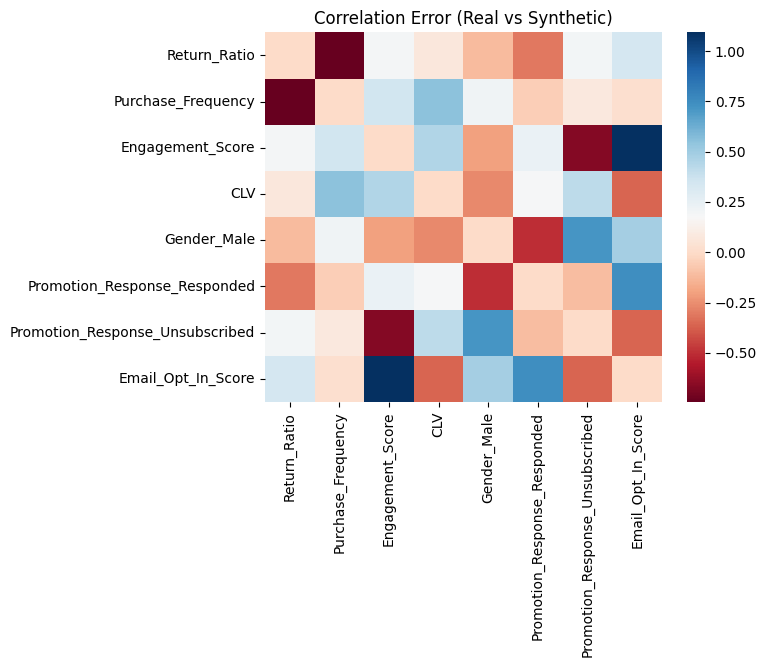

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# 1. Filter only churned customers (assuming Churn=1 is the minority)
churned_data = data[data['Target_Churn'] == 1][feature_columns].values
print(f"Number of churned customers: {churned_data.shape[0]}")

# 2. Scale the data (Crucial for Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(churned_data)
X_tensor = torch.FloatTensor(X_scaled)

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=4):
        super(VAE, self).__init__()
        # Encoder: Compresses features into two vectors: mu and log_var
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(8, latent_dim)
        self.fc_logvar = nn.Linear(8, latent_dim)
        
        # Decoder: Reconstructs the data from the latent space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def reparameterize(self, mu, logvar):
        # The "Trick": Allows gradients to flow through random sampling
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar
    
# Step 3: Define the Loss Function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)
    # KL Divergence helps "regularize" the latent space
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.01 * kl_div # Scaling KL helps stability

# Step 4: Training Loop
model = VAE(input_dim=len(feature_columns))
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    recon_batch, mu, logvar = model(X_tensor)
    loss = vae_loss(recon_batch, X_tensor, mu, logvar)
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Step 5: Generate Synthetic Data
# We throw away the encoder and just use the Decoder to create new customers by feeding it random noise.

def generate_synthetic_churners(model, num_samples, scaler):
    model.eval()
    with torch.no_grad():
        # Sample from the "Latent Space" (Normal distribution)
        noise = torch.randn(num_samples, 4) 
        synthetic_scaled = model.decoder(noise).numpy()
        # Invert the scaling to get real-looking values
        return scaler.inverse_transform(synthetic_scaled)

# Generate 500 new churned customers
new_customers = generate_synthetic_churners(model, 500, scaler)
df_synthetic = pd.DataFrame(new_customers, columns=feature_columns)
df_synthetic['Churn'] = 1


# TEST ON BENCHMARKS
import seaborn as sns
import matplotlib.pyplot as plt

# Compare Correlation Matrices
real_corr = data[data['Target_Churn']==1][feature_columns].corr()
synth_corr = df_synthetic[feature_columns].corr()

# Plot the difference
diff_corr = real_corr - synth_corr
sns.heatmap(diff_corr, annot=False, cmap='RdBu')
plt.title("Correlation Error (Real vs Synthetic)")
plt.show()

Benchmark Explanation: Feature Correlation Stability
A "fake" customer is only useful if the relationships between features are preserved. For example, if in real life Age and CLV are highly correlated, they must be correlated in the synthetic data too. In the heatmap, you want to see mostly zeros (white/neutral colors). Dark red or dark blue spots indicate where the VAE failed to capture a relationship between two variables.

